In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/titanic_cleaned.csv')

print(df.shape)
df.head()

(891, 9)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [43]:
# Feature 1 : Family Size

df['family_size'] = df['sibsp'] + df['parch'] + 1
df[['sibsp', 'parch', 'family_size']].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [44]:
# drop alone, original sibsp, parch since family_size already has these info
df.drop(columns=['alone', 'sibsp', 'parch'], inplace=True)

print(df.shape)
df.columns

(891, 7)


Index(['survived', 'pclass', 'sex', 'age', 'fare', 'embarked', 'family_size'], dtype='str')

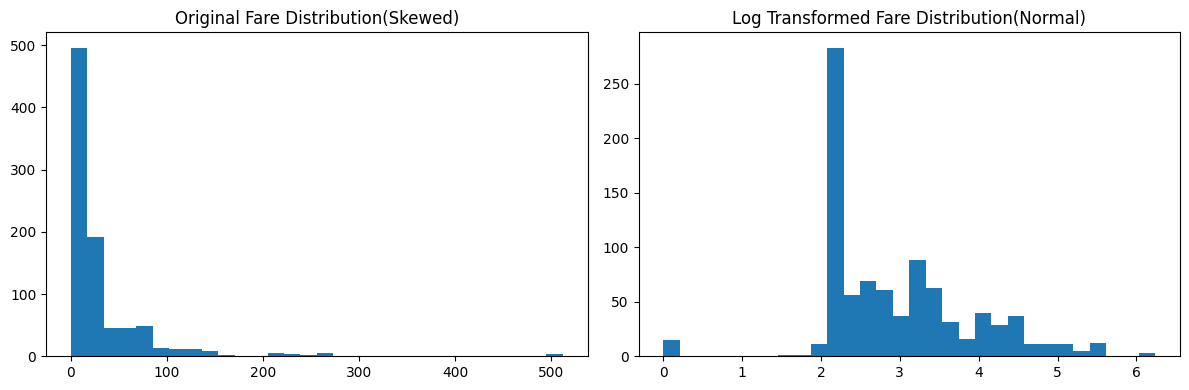

In [45]:
# Log transform fare => to reduce skewness and make it in normal distribution form
df['fare_log'] = np.log1p(df['fare']) # log1p = log(1 + x) instead of log(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['fare'], bins=30)
axes[0].set_title('Original Fare Distribution(Skewed)')

axes[1].hist(df['fare_log'], bins=30)
axes[1].set_title('Log Transformed Fare Distribution(Normal)')

plt.tight_layout()
plt.savefig('../outputs/09_fare_log_transform.png')
plt.show()

In [46]:
# drop original fare
df.drop(columns=['fare'], inplace=True)
print(df.shape)
df.columns

(891, 7)


Index(['survived', 'pclass', 'sex', 'age', 'embarked', 'family_size',
       'fare_log'],
      dtype='str')

In [47]:
#encoding categorical columns : Label encoding, One hot encoding, Target encoding, Ordinal encoding, Binary encoding, Frequency encoding, Hashing encoding, etc

# Feature 4a : Label encode 'sex'
df['sex'] = df['sex'].map({'male':0, 'female':1})

# Feature 4b : one hot encode 'embarked'
#ceates new column per category
df = pd.get_dummies(df,columns=['embarked'], drop_first=True, dtype=int)

print(df.shape)
df.columns


(891, 8)


Index(['survived', 'pclass', 'sex', 'age', 'family_size', 'fare_log',
       'embarked_Q', 'embarked_S'],
      dtype='str')

In [48]:
# convert to memory efficient dtypes
df['pclass'] = df['pclass'].astype('int32')
df['sex'] = df['sex'].astype('int32')
df['family_size'] = df['family_size'].astype('int32')
df['embarked_Q'] = df['embarked_Q'].astype('int32')
df['embarked_S'] = df['embarked_S'].astype('int32')
df['age'] = df['age'].astype('float32')
df['fare_log'] = df['fare_log'].astype('float32')

df.dtypes

survived         int64
pclass           int32
sex              int32
age            float32
family_size      int32
fare_log       float32
embarked_Q       int32
embarked_S       int32
dtype: object

In [49]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (891, 8)

Dtypes:
survived         int64
pclass           int32
sex              int32
age            float32
family_size      int32
fare_log       float32
embarked_Q       int32
embarked_S       int32
dtype: object

Missing values:
survived       0
pclass         0
sex            0
age            0
family_size    0
fare_log       0
embarked_Q     0
embarked_S     0
dtype: int64

First 5 rows:


,survived,pclass,sex,age,family_size,fare_log,embarked_Q,embarked_S
0,0,3,0,22.0,2,2.110213,0,1
1,1,1,1,38.0,2,4.280593,0,0
2,1,3,1,26.0,1,2.188856,0,1
3,1,1,1,35.0,2,3.990834,0,1
4,0,3,0,35.0,1,2.202765,0,1


In [50]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (891, 8)

Dtypes:
survived         int64
pclass           int32
sex              int32
age            float32
family_size      int32
fare_log       float32
embarked_Q       int32
embarked_S       int32
dtype: object

Missing values:
survived       0
pclass         0
sex            0
age            0
family_size    0
fare_log       0
embarked_Q     0
embarked_S     0
dtype: int64

First 5 rows:


,survived,pclass,sex,age,family_size,fare_log,embarked_Q,embarked_S
0,0,3,0,22.0,2,2.110213,0,1
1,1,1,1,38.0,2,4.280593,0,0
2,1,3,1,26.0,1,2.188856,0,1
3,1,1,1,35.0,2,3.990834,0,1
4,0,3,0,35.0,1,2.202765,0,1


In [51]:
#save feaeture engineered data
df.to_csv('../data/processed/titanic_features.csv', index=False)
print("Feature engineered data saved")
print(df.shape)
df.head()

Feature engineered data saved
(891, 8)


,survived,pclass,sex,age,family_size,fare_log,embarked_Q,embarked_S
0,0,3,0,22.0,2,2.110213,0,1
1,1,1,1,38.0,2,4.280593,0,0
2,1,3,1,26.0,1,2.188856,0,1
3,1,1,1,35.0,2,3.990834,0,1
4,0,3,0,35.0,1,2.202765,0,1
